In [68]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [69]:
import numpy as np
import pandas as pd
from src.features import cycle_day_month
from src._xgboost import search_params
from skforecast.recursive import ForecasterRecursive
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
import warnings
from skforecast.exceptions import IgnoredArgumentWarning

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

In [70]:
def process_data(data: pd.DataFrame, start_date: str):
    df = data.copy()
    df = df.asfreq('D')
    df = cycle_day_month(df)
    
    start_date = pd.to_datetime(start_date)
    df['days_from_start'] = (df['Дата'] - start_date).dt.days
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)
    
    return df

def plot_forecast(X_train, y_true, y_pred, title="Прогноз vs Истинные значения"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    ax1.plot(y_true.index, y_true.values, label='Истинные', color='blue', linewidth=1.5)
    ax1.plot(y_pred.index, y_pred.values, label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    ax1.set_xlabel('Дата')
    ax1.set_ylabel('Значение')
    ax1.set_title('Тестовый период')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    ax2.plot(X_train.index, X_train.values, 
             label='Исторические (X_train)', color='green', linewidth=1.5, alpha=0.7)
    ax2.plot(y_true.index, y_true.values, 
             label='Истинные (тест)', color='blue', linewidth=1.5)
    ax2.plot(y_pred.index, y_pred.values, 
             label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    ax2.set_xlabel('Дата')
    ax2.set_ylabel('Значение')
    ax2.set_title('Полный период (история + тест)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
def show_results(model, df_train_full, df_test, target_col, exog_cols):
    y_pred = model.predict(
                steps=len(df_test),
                exog=df_test[exog_cols]
            )

    rmse = np.sqrt(mean_squared_error(df_test[target_col], y_pred))
    print(f'RMSE на тесте = {rmse}')

    plot_forecast(df_train_full[target_col], df_test[target_col], y_pred)
    
def fit_best_model(df_train, best_params, target_col, exog_cols):
    best_model = ForecasterRecursive(xgb.XGBRegressor(**best_params, random_state = 42), 
                                    lags = best_params['lags'])
    best_model.fit(
                y=df_train[target_col],
                exog=df_train[exog_cols],
            )
    return best_model

In [71]:
start_date = '2020-11-27'

df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [72]:
df_train_full = process_data(df_train_full, start_date)
df_train = process_data(df_train, start_date)
df_val = process_data(df_val, start_date)
df_test = process_data(df_test, start_date)

Глубина 0

In [73]:
depth = 0
model_path = f'../xgboost/models/xgb_v1_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'День_sin', 'День_cos', 'days_from_start']

In [74]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-12 16:06:54,776] A new study created in memory with name: no-name-f1f64ec0-c78b-40ef-a10f-0e15dcf5790b
[I 2026-05-12 16:06:54,977] Trial 0 finished with value: 4.802477516506007 and parameters: {'lags': 4, 'n_estimators': 679, 'learning_rate': 0.01588981366407615, 'max_depth': 3, 'subsample': 0.8469023252340508, 'colsample_bytree': 0.8423283834197361, 'colsample_bylevel': 0.6565423608672245, 'colsample_bynode': 0.8936170912206984, 'reg_alpha': 0.18847259094619478, 'reg_lambda': 3.4354131091944984, 'gamma': 0.001238258457445306, 'min_child_weight': 14, 'max_delta_step': 4}. Best is trial 0 with value: 4.802477516506007.
[I 2026-05-12 16:06:55,386] Trial 1 finished with value: 4.176265115283406 and parameters: {'lags': 3, 'n_estimators': 576, 'learning_rate': 0.028873627336094887, 'max_depth': 9, 'subsample': 0.7411818247801845, 'colsample_bytree': 0.7006844379500539, 'colsample_bylevel': 0.5872385921484012, 'colsample_bynode': 0.48226570045219325, 'reg_alpha': 5.6606972608711

Лучшие параметры = {'lags': 3, 'n_estimators': 576, 'learning_rate': 0.028873627336094887, 'max_depth': 9, 'subsample': 0.7411818247801845, 'colsample_bytree': 0.7006844379500539, 'colsample_bylevel': 0.5872385921484012, 'colsample_bynode': 0.48226570045219325, 'reg_alpha': 5.660697260871155e-05, 'reg_lambda': 3.998796852949384e-05, 'gamma': 5.285769171778349e-05, 'min_child_weight': 12, 'max_delta_step': 15}
Лучший RMSE score = 4.176265115283406


In [75]:
best_model = fit_best_model(df_train_full, best_params, target_col, exog_cols)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v1_0']

RMSE на тесте = 3.5954481043984656


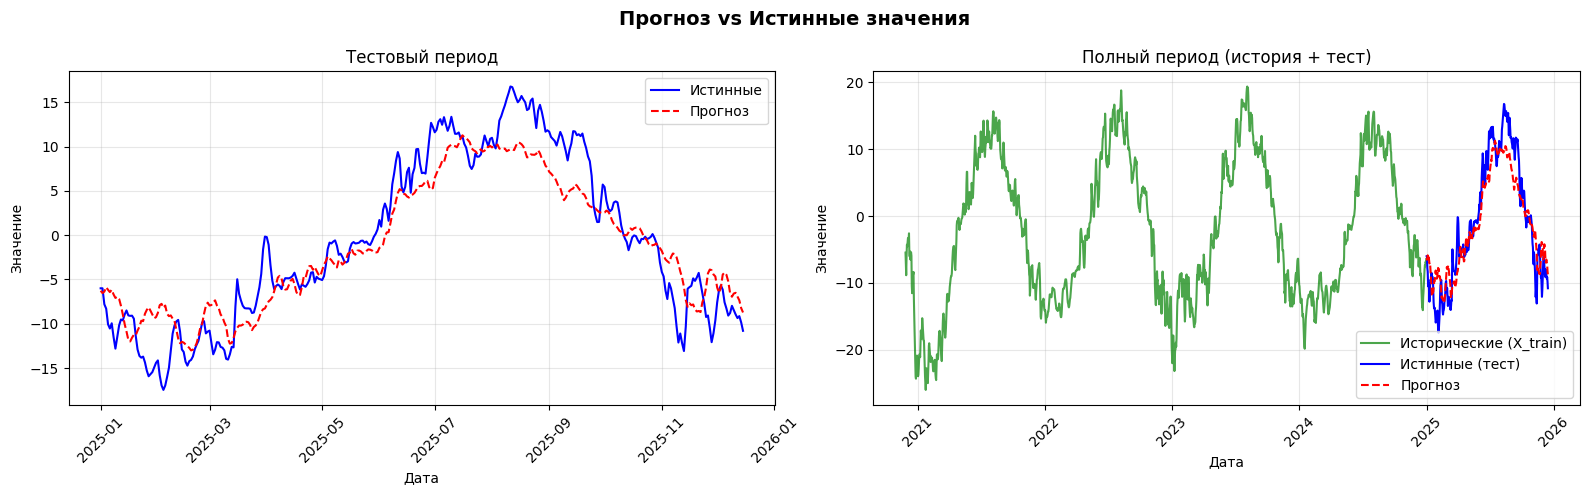

,feature,importance
2,lag_3,0.237965
4,Месяц_cos,0.237182
0,lag_1,0.221849
1,lag_2,0.206473
7,days_from_start,0.058067
3,Месяц_sin,0.029543
5,День_sin,0.005052
6,День_cos,0.003870


In [76]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols)
importances = model.get_feature_importances()
importances

Глубина 5

In [77]:
depth = 5
model_path = f'../xgboost/models/xgb_v1_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'День_sin', 'День_cos', 'days_from_start']

In [78]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-12 16:07:07,075] A new study created in memory with name: no-name-073791a0-e969-4350-93f4-9ce7a0b48d37
[I 2026-05-12 16:07:07,339] Trial 0 finished with value: 1.1811689878931058 and parameters: {'lags': 4, 'n_estimators': 686, 'learning_rate': 0.020492266020240752, 'max_depth': 4, 'subsample': 0.4606027269904574, 'colsample_bytree': 0.635874751582203, 'colsample_bylevel': 0.8895450644016347, 'colsample_bynode': 0.9412615220556096, 'reg_alpha': 0.3265073494960573, 'reg_lambda': 2.5387705013046378, 'gamma': 0.00026460039672173, 'min_child_weight': 6, 'max_delta_step': 2}. Best is trial 0 with value: 1.1811689878931058.
[I 2026-05-12 16:07:07,609] Trial 1 finished with value: 2.0319496069023506 and parameters: {'lags': 5, 'n_estimators': 466, 'learning_rate': 0.00589170658230655, 'max_depth': 7, 'subsample': 0.9688753119637002, 'colsample_bytree': 0.9002435226727185, 'colsample_bylevel': 0.7952658842945965, 'colsample_bynode': 0.5661321663739141, 'reg_alpha': 2.266023275911934

Лучшие параметры = {'lags': 5, 'n_estimators': 955, 'learning_rate': 0.01922834880138614, 'max_depth': 2, 'subsample': 0.44885771049648954, 'colsample_bytree': 0.4125586313009629, 'colsample_bylevel': 0.7825398637345045, 'colsample_bynode': 0.46431565330232794, 'reg_alpha': 0.01162342930617549, 'reg_lambda': 0.0006108110135003715, 'gamma': 0.001568569589627618, 'min_child_weight': 1, 'max_delta_step': 9}
Лучший RMSE score = 0.7397838826211152


In [79]:
best_model = fit_best_model(df_train_full, best_params, target_col, exog_cols)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v1_5']

RMSE на тесте = 0.8152305376421405


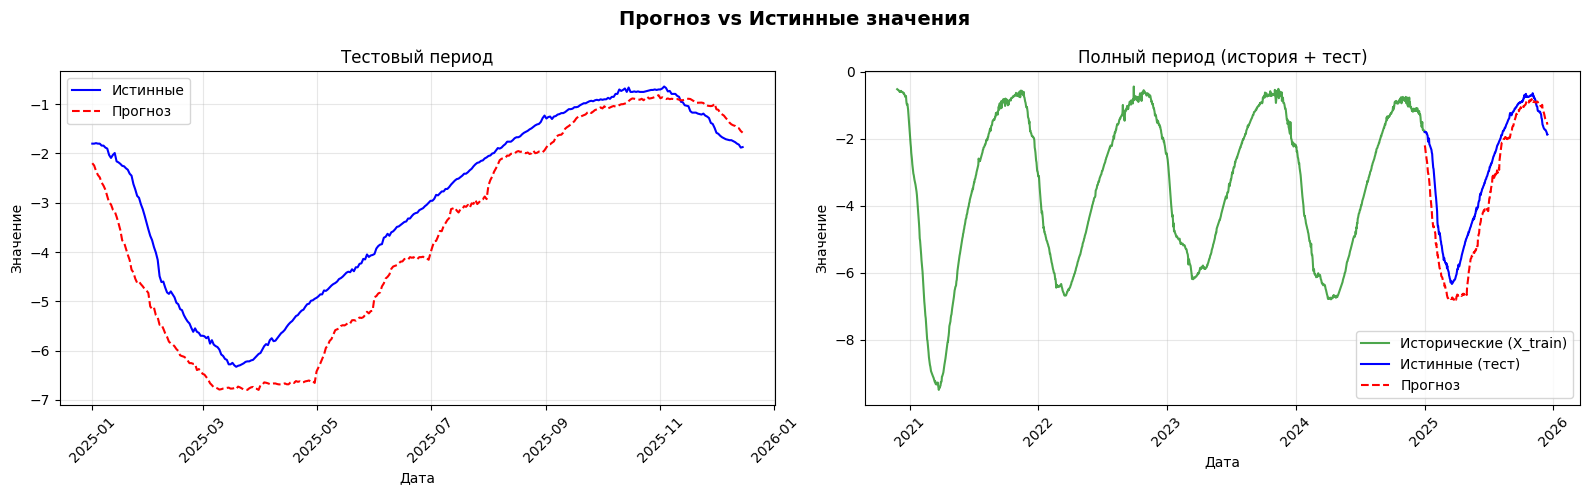

,feature,importance
1,lag_2,0.208349
4,lag_5,0.174399
0,lag_1,0.172201
3,lag_4,0.143569
5,Месяц_sin,0.140505
2,lag_3,0.090249
9,days_from_start,0.051240
6,Месяц_cos,0.015921
8,День_cos,0.002175
7,День_sin,0.001392


In [80]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols)
importances = model.get_feature_importances()
importances

Глубина 10

In [81]:
depth = 10
model_path = f'../xgboost/models/xgb_v1_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'День_sin', 'День_cos', 'days_from_start']

In [82]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-12 16:07:16,714] A new study created in memory with name: no-name-62b45141-427f-4ee4-80bf-4229459d9a08
[I 2026-05-12 16:07:17,118] Trial 0 finished with value: 0.9655699317047824 and parameters: {'lags': 5, 'n_estimators': 946, 'learning_rate': 0.34849218077411764, 'max_depth': 8, 'subsample': 0.6005746329221374, 'colsample_bytree': 0.7340781863845396, 'colsample_bylevel': 0.9931040076618981, 'colsample_bynode': 0.9242472920753316, 'reg_alpha': 0.05169327972518025, 'reg_lambda': 5.563211363621987, 'gamma': 1.986312366685134e-05, 'min_child_weight': 2, 'max_delta_step': 17}. Best is trial 0 with value: 0.9655699317047824.
[I 2026-05-12 16:07:17,372] Trial 1 finished with value: 1.0066348726570167 and parameters: {'lags': 2, 'n_estimators': 570, 'learning_rate': 0.0006380021027320337, 'max_depth': 6, 'subsample': 0.4647114092513788, 'colsample_bytree': 0.7849999654728915, 'colsample_bylevel': 0.5404140098544574, 'colsample_bynode': 0.9080465512783643, 'reg_alpha': 1.2713046584

Лучшие параметры = {'lags': 2, 'n_estimators': 407, 'learning_rate': 0.007554957442212102, 'max_depth': 9, 'subsample': 0.8044434596112164, 'colsample_bytree': 0.6009095962945271, 'colsample_bylevel': 0.9196457683208409, 'colsample_bynode': 0.5157062005126685, 'reg_alpha': 0.00012256841494275231, 'reg_lambda': 3.8911015839764986, 'gamma': 0.024826276753010582, 'min_child_weight': 13, 'max_delta_step': 6}
Лучший RMSE score = 0.6328230884201207


In [83]:
best_model = fit_best_model(df_train_full, best_params, target_col, exog_cols)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v1_10']

RMSE на тесте = 0.30801035391669274


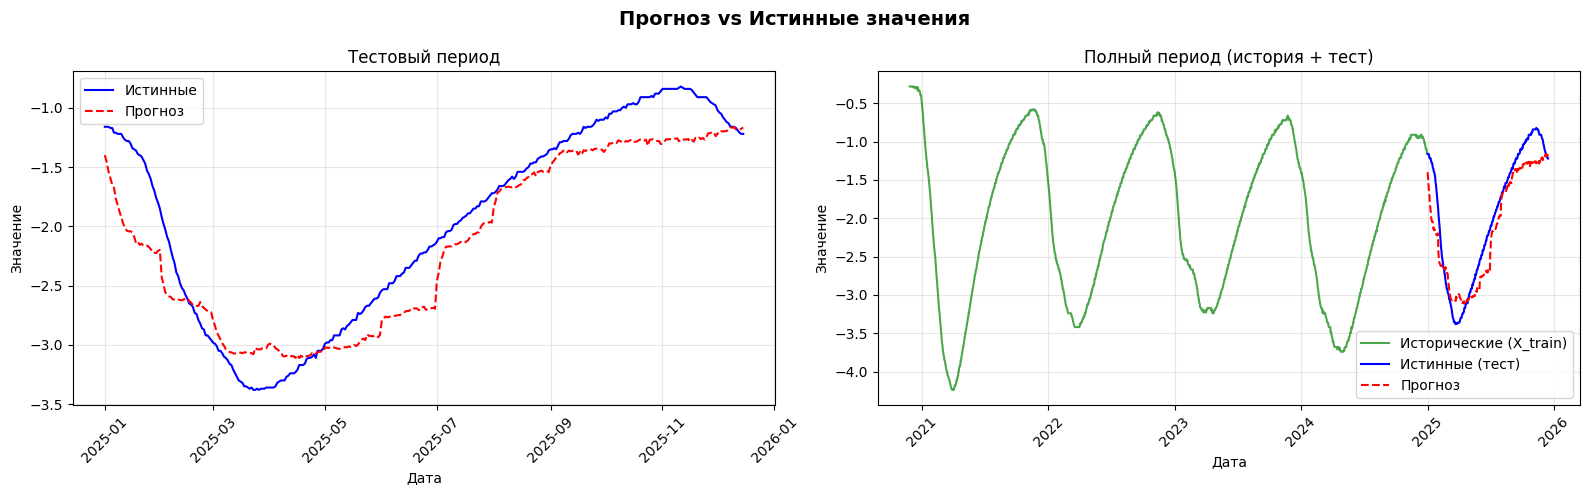

,feature,importance
2,Месяц_sin,0.396151
0,lag_1,0.257130
1,lag_2,0.240383
6,days_from_start,0.067722
3,Месяц_cos,0.031248
4,День_sin,0.004387
5,День_cos,0.002979


In [84]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols)
importances = model.get_feature_importances()
importances